In [2]:
!pip install lightkurve astroquery

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.2/41.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 261.1/261.1 kB 8.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.1/11.1 MB 83.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 60.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.9/203.9 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 63.6 MB/s eta 0:00:00
  Created wheel for fbpca: filename=fbpca-1.0-py3-none-any.whl size=11373 sha256=f4611baa0c776af7cd5fb0ccc9226e7703880c9dafa81660c5d14c055d0e987b
  Stored in directory: /root/.cache/pip/wheels/04/15/cd/2f622795b09e83471a3be5d2581cd9cf96a6ec7aa78e8deffe
  Created wheel for memoization: 

In [3]:
from astroquery.ipac.nexsci.nasa_exoplanet_archive import NasaExoplanetArchive
import pandas as pd
#threshold crossin event(tce)
tce = NasaExoplanetArchive.query_criteria(table="q1_q17_dr25_tce", select="*")
df = tce.to_pandas()
#this is unlabled data
print(f"Total TCEs: {len(df)}")
print(f"Columns: {list(df.columns)}")
print(df.head(3))

Total TCEs: 34032
Columns: ['ra', 'dec', 'tce_delivname', 'tce_datalink_dvr', 'tce_datalink_dvs', 'tce_nkoi', 'kepid', 'tce_plnt_num', 'tce_num_transits', 'tce_max_sngle_ev', 'tce_max_mult_ev', 'tce_fwm_sra_err', 'tce_fwm_sra', 'tce_fwm_sdec_err', 'tce_fwm_sdec', 'tce_fwm_srao_err', 'tce_fwm_srao', 'tce_fwm_sdeco_err', 'tce_fwm_sdeco', 'tce_fwm_prao_err', 'tce_fwm_prao', 'tce_fwm_pdeco_err', 'tce_fwm_pdeco', 'tce_fwm_stat', 'tce_dicco_mdec_err', 'tce_dicco_mdec', 'tce_dicco_mra_err', 'tce_dicco_mra', 'tce_dicco_msky_err', 'tce_dicco_msky', 'tce_dikco_mdec_err', 'tce_dikco_mdec', 'tce_dikco_mra_err', 'tce_dikco_mra', 'tce_dikco_msky_err', 'tce_dikco_msky', 'tce_bin_oedp_stat', 'tce_full_conv', 'tce_limbdark_mod', 'tce_ldm_coeff4', 'tce_ldm_coeff3', 'tce_ldm_coeff2', 'tce_ldm_coeff1', 'tce_trans_mod', 'tce_model_snr', 'tce_model_dof', 'tce_model_chisq', 'tce_time0bk_err', 'tce_time0bk', 'tce_eccen_err', 'tce_eccen', 'tce_longp_err', 'tce_longp', 'tce_prad_err', 'tce_prad', 'tce_sma_err',

In [4]:
import re
import pandas as pd
from io import StringIO
import requests

url = "https://raw.githubusercontent.com/nasa/kepler-robovetter/master/kplr_dr25_obs_robovetter_output.txt"
raw = requests.get(url).text
robovetter = pd.read_csv(StringIO(raw), sep=r'\s+', header=0)

robovetter.columns = ['tce_id', 'robovetter_score', 'disposition',
                      'not_transit_like', 'stellar_eclipse',
                      'centroid_offset', 'offset_flag_split',
                      'ephemeris_match', 'minor_flags']

# centroid_offset is already correct (col 6), drop the split artifact
robovetter = robovetter.drop(columns=['offset_flag_split'])

# parse kepid and planet number out of tce_id (format: 000757099-01)
robovetter['kepid'] = robovetter['tce_id'].str[:9].astype(int)
robovetter['tce_plnt_num'] = robovetter['tce_id'].str[10:].astype(int)

print(robovetter[['tce_id', 'kepid', 'tce_plnt_num', 'disposition', 'robovetter_score']].head(5))
print()
print(robovetter['disposition'].value_counts())
print(f"\nTotal: {len(robovetter)}")

         tce_id   kepid  tce_plnt_num disposition  robovetter_score
0  000757099-01  757099             1          FP             0.000
1  000757450-01  757450             1          PC             0.999
2  000892376-01  892376             1          FP             0.000
3  000892376-02  892376             2          FP             0.000
4  000892376-03  892376             3          FP             0.000

disposition
FP    28497
PC     4037
Name: count, dtype: int64

Total: 32534


In [5]:
# merge robovetter labels with TCE feature columns
merged = pd.merge(df, robovetter[['kepid', 'tce_plnt_num', 'disposition', 'robovetter_score']],
                  on=['kepid', 'tce_plnt_num'],
                  how='inner')

print(f"Merged rows: {len(merged)}")
print()
print(merged[['kepid', 'tce_plnt_num', 'tce_period', 'tce_duration', 'tce_depth', 'tce_model_snr', 'disposition']].head(5))
print()
print(merged['disposition'].value_counts())

Merged rows: 32534

     kepid  tce_plnt_num  tce_period  tce_duration  tce_depth  tce_model_snr  \
0  2304168             2  431.719000        13.220    488.400         10.320   
1  2304235             1    0.570607         1.160     75.150         20.390   
2  2304566             1    0.689480         5.236      3.794          2.574   
3  2304320             1   16.540800         2.715    366.700         30.830   
4  2303365             2    0.520697         1.035    123.600         18.950   

  disposition  
0          FP  
1          FP  
2          FP  
3          PC  
4          FP  

disposition
FP    28497
PC     4037
Name: count, dtype: int64


In [7]:
pc=merged[merged['disposition']== 'PC']
fp=merged[merged['disposition']=='FP'].sample(n=4037, random_state=42)

balanced=pd.concat([pc,fp]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Balanced dataset size: {len(balanced)}")
print(balanced['disposition'].value_counts())
print()
print(balanced[['kepid','tce_period','tce_duration','tce_depth','disposition']].head(5))

balanced.to_csv('balanced_tce.csv',index=False)
print("\n Saved to balanced_tce.csv")

Balanced dataset size: 8074
disposition
PC    4037
FP    4037
Name: count, dtype: int64

      kepid  tce_period  tce_duration  tce_depth disposition
0   5629538    15.18740         4.428     290.90          PC
1   5479800   474.37400         6.406    3315.00          FP
2  10397751     2.90512         2.277      47.73          PC
3  10141900     4.09668         2.407     254.20          PC
4  11513790   416.15300        15.070     367.50          FP

 Saved to balanced_tce.csv


/usr/local/lib/python3.12/dist-packages/lightkurve/prf/__init__.py:7: UserWarning: Warning: the tpfmodel submodule is not available without oktopus installed, which requires a current version of autograd. See #1452 for details.
  warnings.warn(


Fetching star KIC 5629538 — period: 15.1874 days


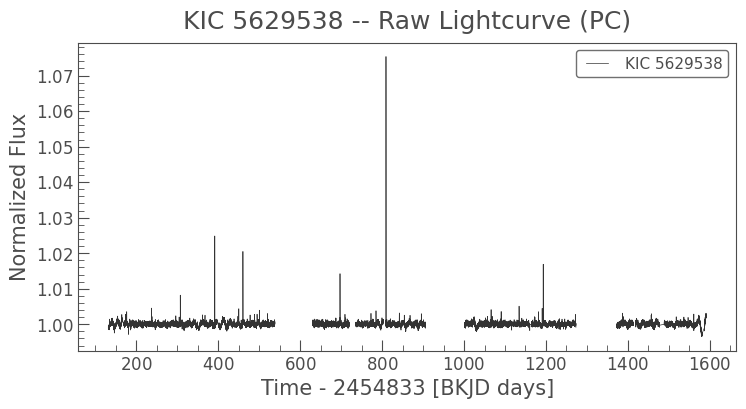

In [9]:
import lightkurve as lk
import matplotlib.pyplot as plt

#picking a planet
sample_pc=balanced[balanced['disposition']=='PC'].iloc[0]
print(f"Fetching star KIC {sample_pc['kepid']} — period: {sample_pc['tce_period']} days")

#fetching lightcurve
lc_collection=lk.search_lightcurve(
    f"KIC {sample_pc['kepid']}",
    mission="Kepler",
    cadence="long"
).download_all()

#stitch it all together
lc=lc_collection.stitch()

#plot
lc.plot(title=f"KIC {sample_pc["kepid"]} -- Raw Lightcurve (PC)")
plt.show()


/usr/local/lib/python3.12/dist-packages/lightkurve/lightcurve.py:3510: UserWarning: n_bins is no longer accepted for FoldedLightCurve objects. Please specify 'bins' instead
  warnings.warn(


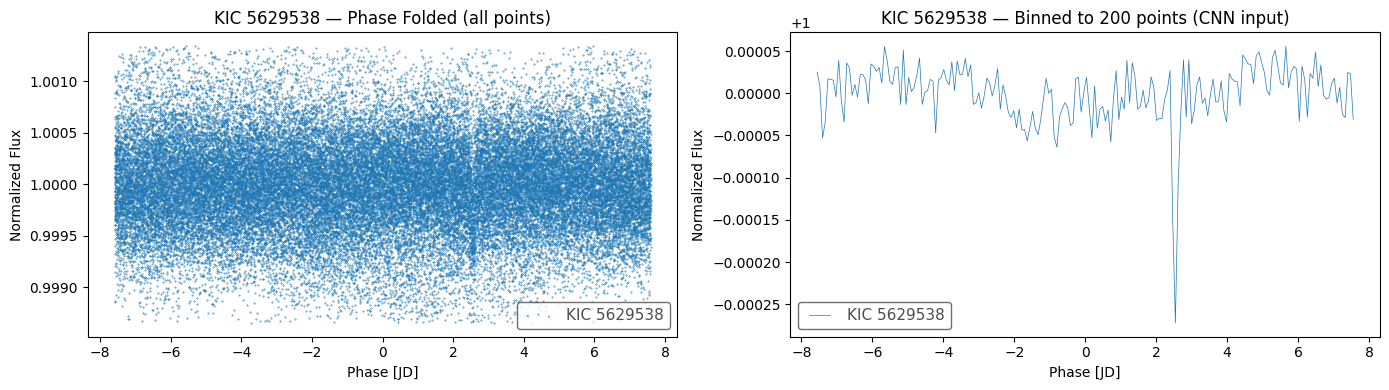

Binned array shape: (200,)


In [10]:
# remove outlier spikes first
lc_clean = lc.remove_outliers(sigma=3)

# phase-fold on the known period — this collapses 4 years into one orbital cycle
folded = lc_clean.fold(period=sample_pc['tce_period'])

# bin it down to 200 points — this is the array your CNN will train on
binned = folded.bin(n_bins=200)

# plot
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

folded.scatter(ax=axes[0], s=0.5)
axes[0].set_title(f"KIC {sample_pc['kepid']} — Phase Folded (all points)")

binned.plot(ax=axes[1])
axes[1].set_title(f"KIC {sample_pc['kepid']} — Binned to 200 points (CNN input)")

plt.tight_layout()
plt.show()

print(f"Binned array shape: {binned.flux.shape}")

Fetching FP star KIC 5479800 — period: 474.374 days


/usr/local/lib/python3.12/dist-packages/lightkurve/lightcurve.py:3510: UserWarning: n_bins is no longer accepted for FoldedLightCurve objects. Please specify 'bins' instead
  warnings.warn(


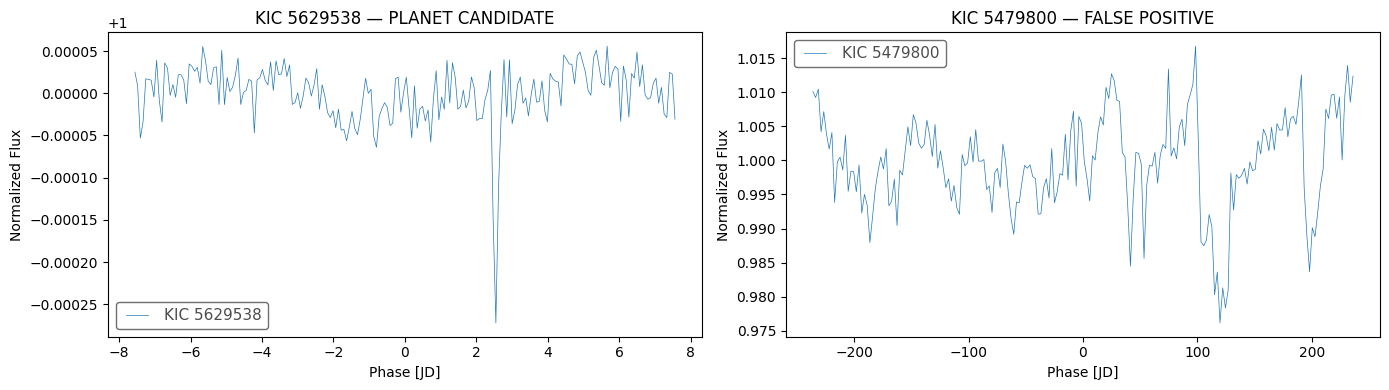

In [11]:
# grab a false positive from your dataset
sample_fp = balanced[balanced['disposition'] == 'FP'].iloc[0]
print(f"Fetching FP star KIC {sample_fp['kepid']} — period: {sample_fp['tce_period']} days")

lc_fp = lk.search_lightcurve(
    f"KIC {sample_fp['kepid']}",
    mission="Kepler",
    cadence="long"
).download_all().stitch().remove_outliers(sigma=3)

folded_fp = lc_fp.fold(period=sample_fp['tce_period'])
binned_fp = folded_fp.bin(n_bins=200)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

binned.plot(ax=axes[0])
axes[0].set_title(f"KIC {sample_pc['kepid']} — PLANET CANDIDATE")

binned_fp.plot(ax=axes[1])
axes[1].set_title(f"KIC {sample_fp['kepid']} — FALSE POSITIVE")

plt.tight_layout()
plt.show()

In [12]:
from google.colab import files
files.download('balanced_tce.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>